# Seaborn常用图像绘制
----

##### 使用sns.load_dataset() 加载数据集
```
searborn提供了很多实验数据集，查看数据集有哪些可以参考如下网址：
https://github.com/mwaskom/seaborn-data
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
iris = sns.load_dataset('iris')

In [9]:
titanic = sns.load_dataset('titanic')

In [7]:
tips = sns.load_dataset('tips')

In [8]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [10]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [11]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## 普通2D图像

### 通用参数：
```
x,y:  要展示的数据，如果是DataFrame，可以设置列标签
data:  数据的来源，通常是一个DataFrame
hue:  分组因子, 用于颜色映射的列
palette:  用于颜色映射的调色板
order:  排序的序列.例如 order = ['Dinner', 'Lunch']
hue_order: 颜色映射的序列， 例如hue_order = ["setosa","virginica"]

```

### 条形图
```
比较多组数据之间的大小
sns.barplot()
```

参数说明：
```
estimator: 统计参数默认为 np.mean,可自定义： np.sum, np.count_nonzero, np.median...
palette: 主题的颜色 palette = 'Blues_d'
ci: 置信水平  http://www.360doc.com/content/18/0317/16/15033922_737796626.shtml
```

In [13]:
data = np.array([4, 6, 3, 9])
labels = list('abcd')

<BarContainer object of 4 artists>

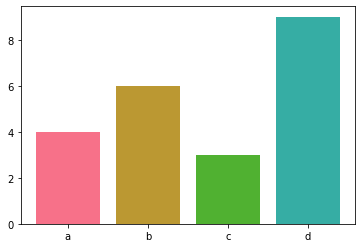

In [15]:
plt.bar(labels, data, color=sns.color_palette('husl'))

In [17]:
# 各类鸢尾花的sepal_length的平均值大小对比
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


<BarContainer object of 3 artists>

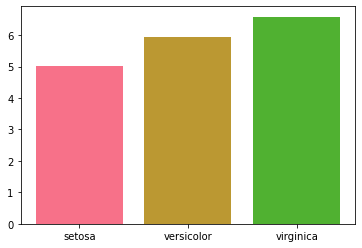

In [22]:
sepal_length_mean = iris.groupby('species')['sepal_length'].mean()

plt.bar(x=sepal_length_mean.index, height=sepal_length_mean.values, color=sns.color_palette('husl'))

In [23]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
0  100  取整数  离散字段

0  100  无限取值 连续字段

<AxesSubplot:xlabel='species', ylabel='sepal_length'>

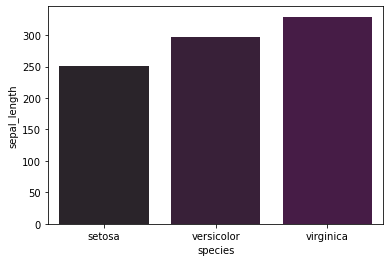

In [35]:
# x y 必须是一个离散字段

# 置信水平 

# 置信水平：  推断 区间估计
sns.barplot(x='species', y='sepal_length', data=iris,
            estimator=np.sum, ci=None, palette=sns.dark_palette('purple'))

<AxesSubplot:xlabel='sepal_length', ylabel='species'>

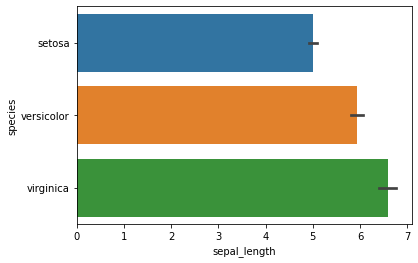

In [30]:
sns.barplot(x='sepal_length', y='species', data=iris, estimator=np.mean)

In [38]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [42]:
temp_data.values

array([22.2845    , 19.79123711, 17.97787879, 18.10518519])

In [48]:
for i in temp_data.index:
    print('-'.join(i))

Male-Yes
Male-No
Female-Yes
Female-No


<BarContainer object of 4 artists>

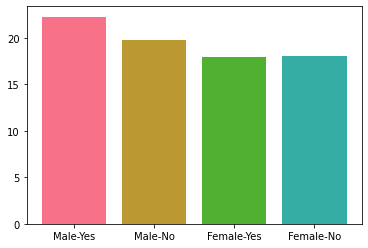

In [53]:
temp_data = tips.groupby(['sex','smoker'])['total_bill'].mean()

plt.bar(x=temp_data.index.map(lambda x: '-'.join(x)), 
        height=temp_data.values,color=sns.color_palette('husl'))

In [56]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<AxesSubplot:xlabel='sex', ylabel='total_bill'>

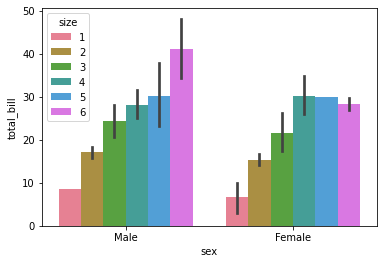

In [60]:
# hue就是分组因子， 在x或y的基础上，再分组，hue指定哪一列，就根据哪一列分组
# hue只解决2次分组问题， 多次分组，就不适合了，有方案Grid
sns.barplot(x='sex', y='total_bill', data=tips, hue='size', palette='husl')

<AxesSubplot:xlabel='total_bill', ylabel='day'>

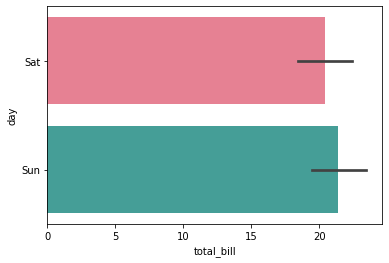

In [71]:
# order  对x或y的离散字段，进行排序或选择, 注意order接收的是字段的内容，不能乱写
sns.barplot(x='total_bill', y='day', data=tips, palette='husl', 
            order=['Sat','Sun'])

<AxesSubplot:xlabel='day', ylabel='total_bill'>

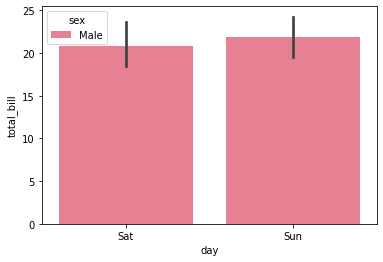

In [79]:
# hue_order  对hue的字段内容进行排序或选择
sns.barplot(x='day', y='total_bill', data=tips, palette='husl', order=['Sat','Sun'],
           hue='sex', hue_order=['Male'])

### 计数条形图
```
统计数据出现次数
sns.countplot()

eg.按性别统计titanic号中幸存者数量
```

<BarContainer object of 2 artists>

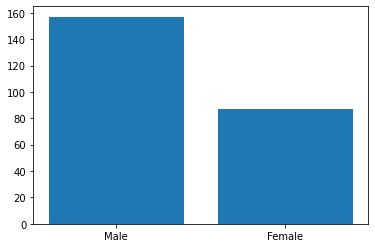

In [83]:
sex_data = tips['sex'].value_counts()

plt.bar(sex_data.index, sex_data.values)

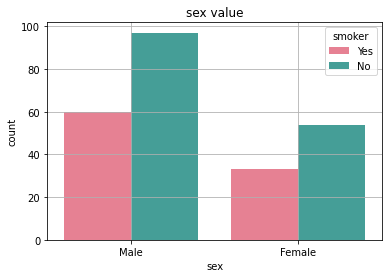

In [90]:
sns.countplot(x='sex', data=tips, hue='smoker', palette='husl')

plt.title('sex value')
plt.grid()

### 散点图

```
查看两组数据对应关系
sns.scatterplot()
sns.stripplot()
```

In [95]:
iris.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

Text(0, 0.5, 'sepal_length')

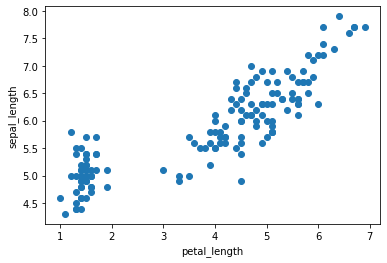

In [93]:
plt.scatter(x=iris.petal_length, y=iris.sepal_length)
plt.xlabel('petal_length')
plt.ylabel('sepal_length')

In [ ]:
10  1.2  1.5  1.89  1.35     连续

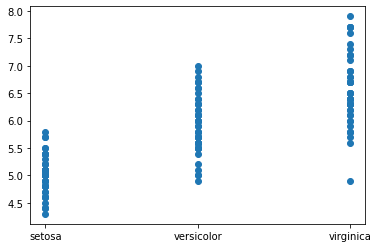

In [96]:
# matplotlib 标准的scatter，是用来展示连续字段和连续字段的对应关系
# 如果是离散字段和连续字段之间，是不容易展示相对关系
# 想查看一种变量的分布形态，要使用箱线图或者是直方图
plt.scatter(x=iris.species, y=iris.sepal_length)

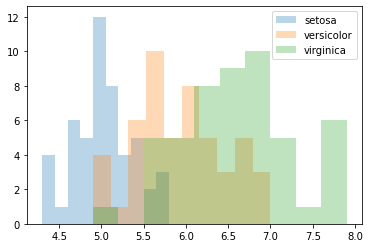

In [102]:
# 离散字段 VS 连续字段
for categoray in iris.species.unique():
    plt.hist(iris.loc[iris.species == categoray, 'sepal_length'], alpha=0.3, label=categoray)

plt.legend()

In [103]:
# 散点图只展示 连续字段和连续字段之间的关系
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


<AxesSubplot:xlabel='sepal_length', ylabel='petal_length'>

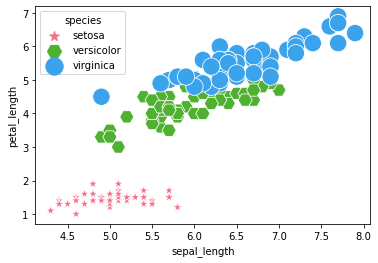

In [145]:
# size 是指定用哪一列的值来配置点的大小
# 如果size指定的列是数值型，可以直接影响点的大小
# 如果size指定的列不是数值型, 那么需要配置sizes参数,dict

# style用来指定哪一列要配置外观
# style 配合 markers（dict）参数来对外观进行定制
sns.scatterplot(x='sepal_length', y='petal_length',data=iris, hue='species', 
                palette='husl', style='species', markers={
                    'setosa':'*',
                    'versicolor':'H',
                    'virginica':'o'
                }, size='species',sizes={
                    'setosa':100,
                    'versicolor':200,
                    'virginica':300
                })

### 分簇散点图，与stripplot()的区别就是点不重叠

```
sns.swarmplot()
```

<AxesSubplot:xlabel='species', ylabel='petal_length'>

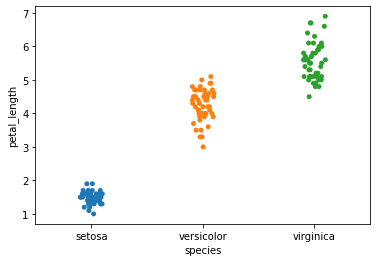

In [146]:
# 比plt.scatter高级，可以看到数据的分布形态
sns.stripplot(x='species', y='petal_length', data=iris)

C:\Users\Dancer\miniconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 14.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<AxesSubplot:xlabel='species', ylabel='petal_length'>

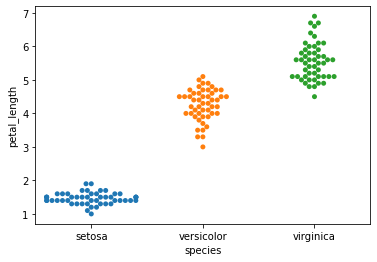

In [147]:
sns.swarmplot(x='species', y='petal_length', data=iris)

### 小提琴图
```
用于查看数据分布情况
sns.violinplot()
```

<AxesSubplot:xlabel='species', ylabel='petal_length'>

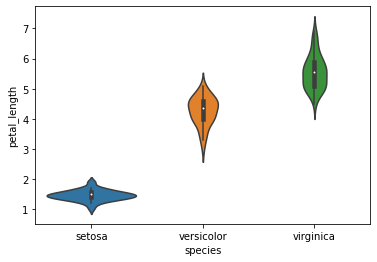

In [151]:
sns.violinplot(x='species', y='petal_length', data=iris, split=False,)

In [152]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<AxesSubplot:xlabel='sex', ylabel='total_bill'>

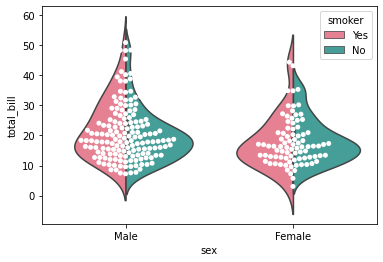

In [161]:
# 演示琴图的分裂特性

sns.violinplot(x='sex', y='total_bill', data=tips, split=True, hue='smoker', palette='husl')
sns.swarmplot(x='sex', y='total_bill', data=tips, color='white')

### 箱线图

```
检验连续数据是否存在离群点，以及数据分布的范围（4分位数）
sns.boxplot()
可以配合结合sns.swarmplot()函数使用
```
参数说明
```
y: 需要判断的数据序列（连续型数据）
x: 分类的标签的数据（离散型数据）
palette: 调色板...Set1, Set2, Set3
linwidth: 线宽(2.5相当于加粗的线)
orient = 'h' 方向
whis 参数设定是否显示箱线图的离群点， whis = np.inf 表示不显示
```

<AxesSubplot:xlabel='tip', ylabel='sex'>

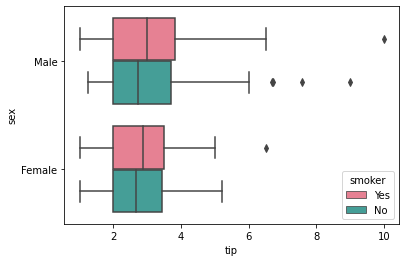

In [167]:
sns.boxplot(y='sex', x='tip', data=tips, palette='husl', hue='smoker')

### 热图
```
sns.heatmap(data=data, annot=True)
```
参数说明：
```
vmin颜色值映射的最小值
vmax颜色值映射的最大值
cbar：每个变量的颜色棒是否显示
annot = True 将数值显示到图上
```

In [173]:
red_map = sns.light_palette('red', as_cmap=True)

<AxesSubplot:>

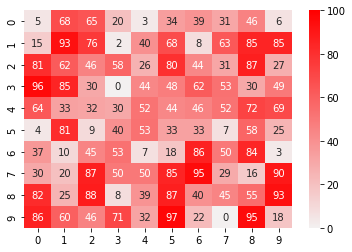

In [174]:
# 重点关注极大值
data = np.random.randint(0, 100, size=(10, 10))

sns.heatmap(data, annot=True, vmin=0, vmax=100, cmap=red_map)

In [188]:
diverging_map = sns.choose_colorbrewer_palette(data_type='diverging',as_cmap=True)

interactive(children=(Dropdown(description='name', options=('RdBu', 'RdGy', 'PRGn', 'PiYG', 'BrBG', 'RdYlBu', …

<AxesSubplot:>

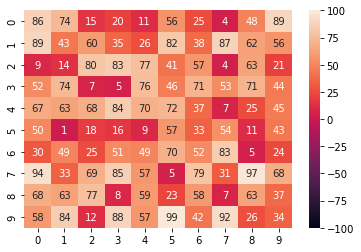

In [192]:
# 重点关注极值

vmin = -100
vmax = 100

data = np.random.randint(0, 100, size=(10, 10))
sns.heatmap(data, annot=True, vmin=vmin, vmax=vmax)

##### 扩展
df.corr() 计算两组数据的相关性
```
三个相关性系数（pearson, spearman, kendall）反应的都是两个变量之间变化趋势的方向以及程度，其值范围为-1到+1，0表示两个变量不相关，正值表示正相关，负值表示负相关，值越大表示相关性越强。
```

```
method : {'pearson', 'kendall', 'spearman'}
pearson : 当数据满足正态性时可用Pearson相关系数查看变量间关系情况
spearman : 当数据为定量数据，且不服从正态性则使用Spearman相关系数
kendall : Kendall相关系数通常用于评分数据一致性水平研究，比如评委打分，数据排名等。
```

<AxesSubplot:>

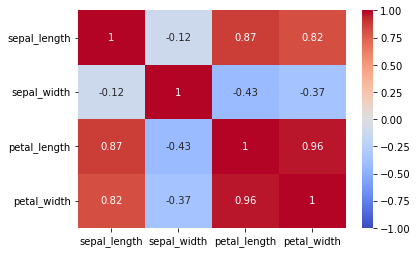

In [197]:
sns.heatmap(iris.corr(), annot=True, vmin=-1, vmax=1, cmap='coolwarm')

## 高级函数
```针对数据可视化的不同目的，seaborn提供了**relplot()，catplot()，displot()，lmplot()**四大主要高级函数。

seaborn与pandas的DataFrame的结合非常好，因此传参是可以直接传入列名。
返回的是FacetGrid(平面网格图)对象。```

这些高级函数的主要参数如下：
```
- x，y：输入变量
- data：输入数据df
- hue：分组变量
- style：如传入，则hue分组后每组数据作图风格可不一致
- col，row：决定平面网格图布局的变量
- kind：底层作图类型名称，如"line",“bar”,"box"等
```

### 可视化变量关系（relationship)

```
regplot() 方便观察变量间的关系， 默认是散点图
lmplot()  x和y必须以字符串的方式传入，比regplot更加严格
```
参数说明：
```
 x_jitter, y_jitter: 给离散型数据添加抖动（仅适用于离散型数据）,且不会影响拟合的回归线本身
 x_estimator: 当x轴为离散数据时，指定y轴上的数据的运算函数，np.mean、np.median...
 order: 如果数据的分布规律是非线性的，设置order>1的任意值，则使用多项式回归来绘制回归曲线
```

<AxesSubplot:xlabel='total_bill', ylabel='tip'>

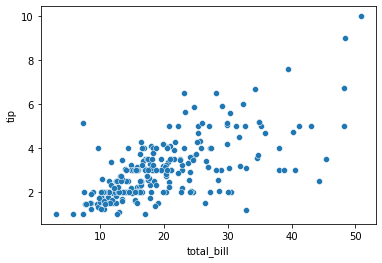

In [207]:
sns.scatterplot(x='total_bill', y='tip', data=tips)

<AxesSubplot:xlabel='total_bill', ylabel='tip'>

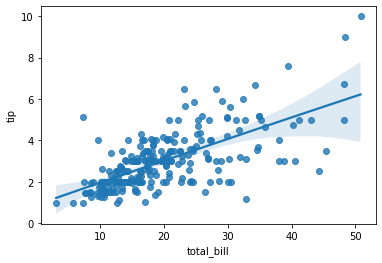

In [214]:
sns.regplot(x='total_bill', y='tip', data=tips, order=2)

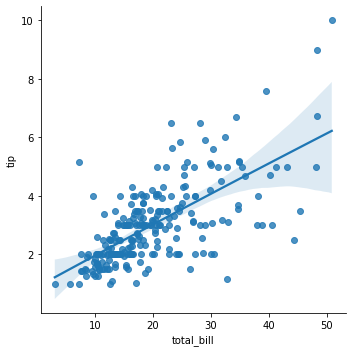

In [215]:
sns.lmplot(x='total_bill', y='tip', data=tips, order=2)

### 数据集分布图(distribution)
```
特征工程前，需要对数据集的有一个整体的了解，seabon提供的高级函数displot()可以作各种分布图。
```

1.单变量分布 
```
distplot() 
histplot()
kdeplot()
rugplot()
```

参数说明：
```
bins: 数据分布区间个数
axlabel: 横轴标签
label: 图例标签
kde: 是否显示核密度估计，如果开启，则数据以归一化方式显示
rug: 是否显示地毯图
（kde、hist、sug）kws: 外观属性设置
norm_hist: 是否归一化处理，需要关闭kde显示

```

In [265]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

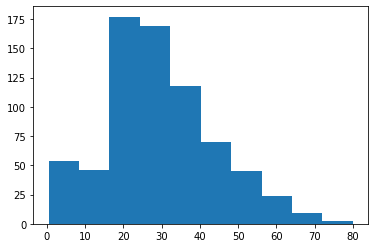

In [266]:
plt.hist(titanic.age)

In [268]:
import warnings

warnings.filterwarnings('ignore')

<AxesSubplot:xlabel='age'>

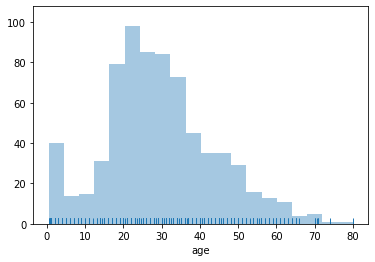

In [271]:
sns.distplot(a=titanic.age, kde=False, rug=True)

<AxesSubplot:xlabel='age', ylabel='Count'>

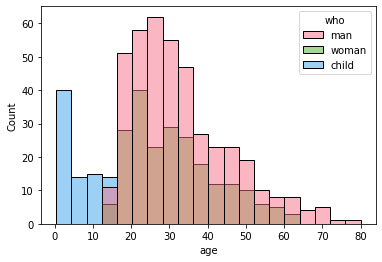

In [277]:
sns.histplot(data=titanic, x='age', hue='who', palette='husl')

<AxesSubplot:xlabel='age', ylabel='Density'>

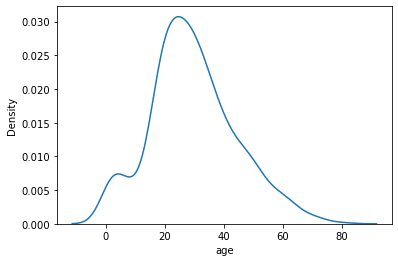

In [273]:
sns.kdeplot(data=titanic, x='age')

<AxesSubplot:xlabel='age'>

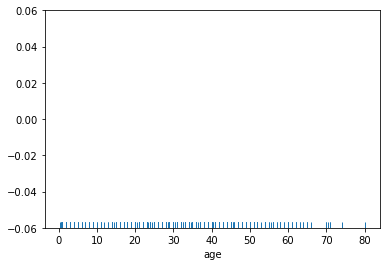

In [274]:
sns.rugplot(data=titanic, x='age')

2.双变量分布 
```
jointplot()
```
参数说明：
```
xlim、ylim: 横、纵轴界限
space: 主画布和分支画布之间的距离（0~1浮点）
marginal_kws：分支画布外观属性
joint_kws：主画布外观属性 , 散点图具备的属性都可以通过字典的方式进行设置
```

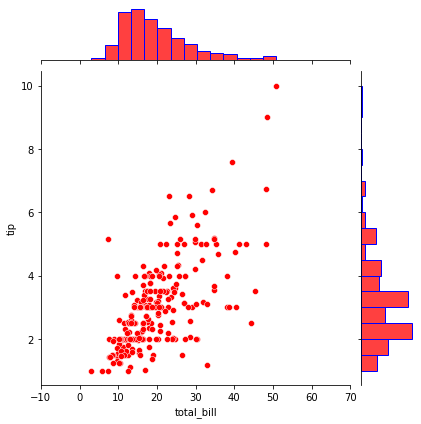

In [283]:
sns.jointplot(x='total_bill', y='tip', data=tips, xlim=[-10, 70], marginal_kws={
    'color':'red',
    'edgecolor':'blue'
}, joint_kws={
    'color':'red'
})

3.成对变量分布 
```
pairplot()
```
参数说明：
```
vars、x_vars, y_vars: 要进行显示的列
markers: 分组数据的点型，列表
```

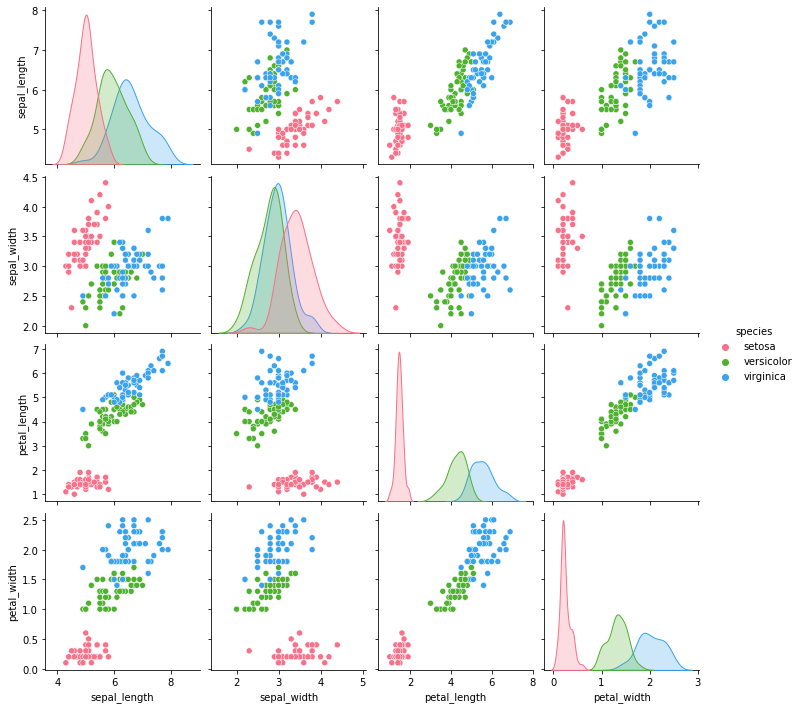

In [288]:
sns.pairplot(data=iris, hue='species', palette='husl')

## 绘制多层面板分类图

factorplot()，可以以更多的子视图展示更多的数据关系

也可以使用FacetGrid()对象

### 参数说明：
```
x,y,hue 数据集变量 变量名
date 数据集 数据集名
row,col 更多分类变量进行平铺显示 变量名
col_wrap 每行的最高平铺数 整数
estimator 在每个分类中进行矢量到标量的映射 矢量
ci 置信区间 浮点数或None
n_boot 计算置信区间时使用的引导迭代次数 整数
units 采样单元的标识符，用于执行多级引导和重复测量设计 数据变量或向量数据
order, hue_order 对应排序列表 字符串列表
row_order, col_order 对应排序列表 字符串列表
kind : 可选：point 默认, bar 柱形图, count 频次, box 箱体, violin 提琴, strip 散点，swarm 分散点（具体图形参考文章前部的分类介绍）
size 每个面的高度（英寸） 标量
aspect 纵横比 标量
orient 方向 "v"/"h"
color 颜色 matplotlib颜色
palette 调色板 seaborn颜色色板或字典
legend hue的信息面板 True/False
legend_out 是否扩展图形，并将信息框绘制在中心右边 True/False
share{x,y} 共享轴线 True/False
facet_kws FacetGrid的其他参数 字典
```

In [293]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<AxesSubplot:xlabel='sex', ylabel='total_bill'>

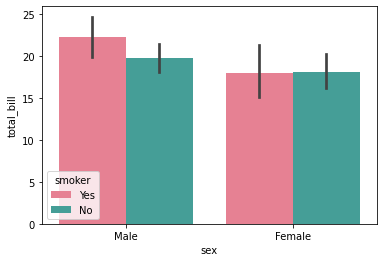

In [292]:
sns.barplot(x='sex', y='total_bill', data=tips, hue='smoker', palette='husl')

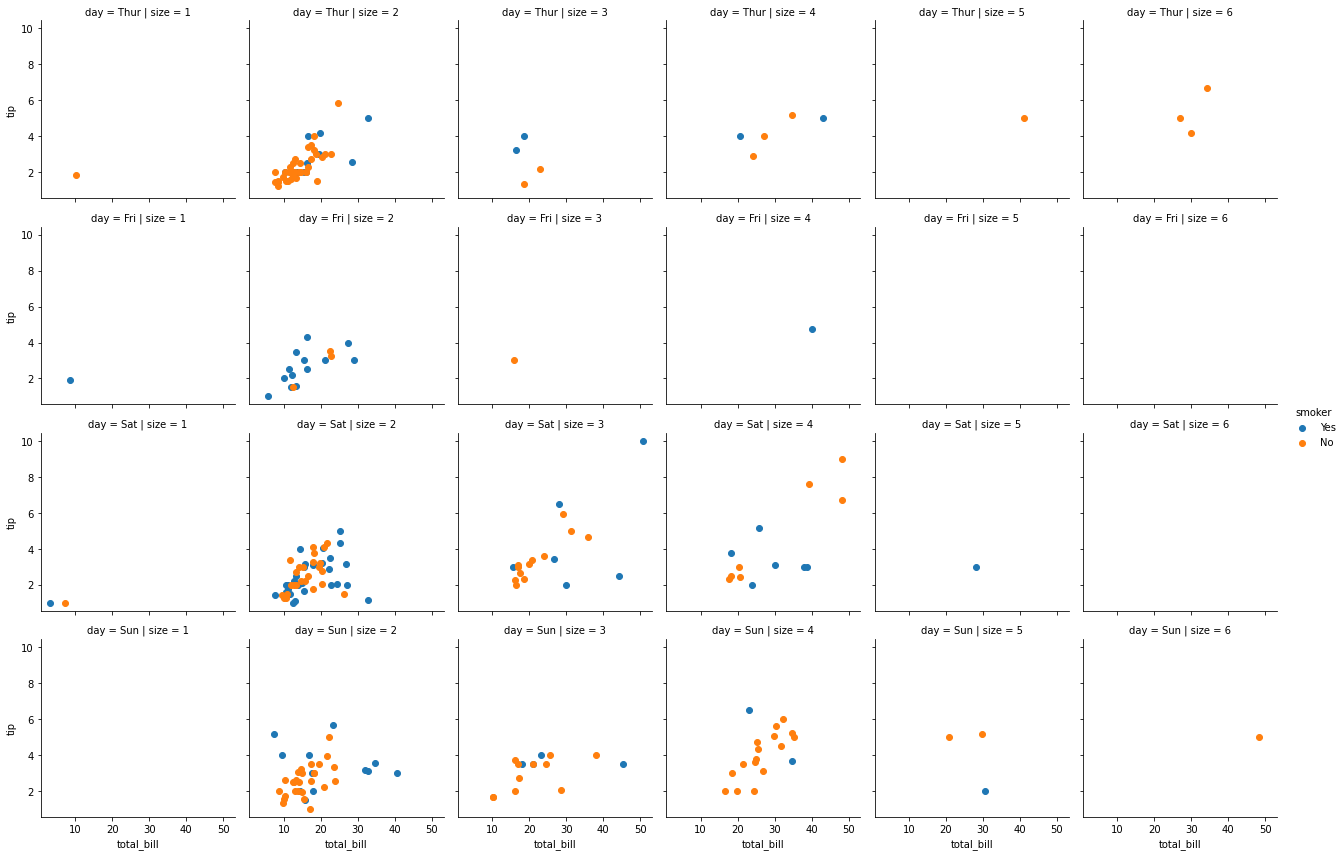

In [297]:
factgrid = sns.FacetGrid(data=tips, row='day', col='size', hue='smoker')

factgrid.map(plt.scatter, 'total_bill', 'tip').add_legend()

In [298]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


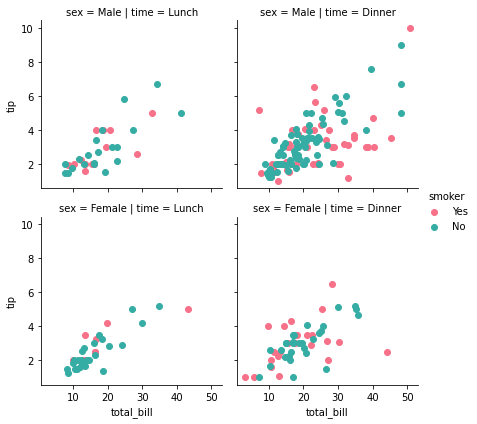

In [300]:
# 子画布分割： 横轴 sex  纵轴  time

# 每个子画布，绘制散点图表示total_bill tip的关系 ， 并且按照smoker分组

factgrid = sns.FacetGrid(data=tips, row='sex', col='time', hue='smoker', palette='husl')

factgrid.map(plt.scatter, 'total_bill', 'tip').add_legend()